# DeiT (Data-efficient Image Transformer)
## Chest X-Ray Pneumonia Classification — PyTorch

### সব আগের fix প্রযোজ্য:
| Fix | Details |
|-----|---------|
| RandomErasing | ToTensor()-এর **পরে** (PIL bug fix) |
| Downsampling | PNEUMONIA undersampled → balanced |
| Progressive Unfreeze | Epoch 1-3 frozen, তারপর lr/10 unfreeze |
| Label Smoothing 0.1 | Overfitting কমায় |
| L2 Weight Decay 1e-3 | AdamW regularization |
| Dropout 0.4 | Head-এ regularization |

### Two setups trained:
| Setup | Description |
|-------|-------------|
| Baseline | Preprocessing only (no augmentation) |
| Augmented | Preprocessing + Data Augmentation |

## 0. Imports

In [1]:
import os, time, math, random, copy, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
import timm

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print(f'timm   : {timm.__version__}')

Device : cuda
PyTorch: 2.10.0+cu128
timm   : 1.0.25


## 1. Dataset Download

In [2]:
import kagglehub
dl_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')

BASE_DIR = dl_path
for root, dirs, _ in os.walk(dl_path):
    if all(f in dirs for f in ['train', 'test', 'val']):
        BASE_DIR = root; break

TRAIN_DIR   = os.path.join(BASE_DIR, 'train')
TEST_DIR    = os.path.join(BASE_DIR, 'test')
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']
print('Base:', BASE_DIR)

Base: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray


## 2. EDA — Class Distribution

Class  NORMAL  PNEUMONIA  Total
Split                          
test      234        390    624
train    1341       3875   5216
val         8          8     16
Total    1583       4273   5856


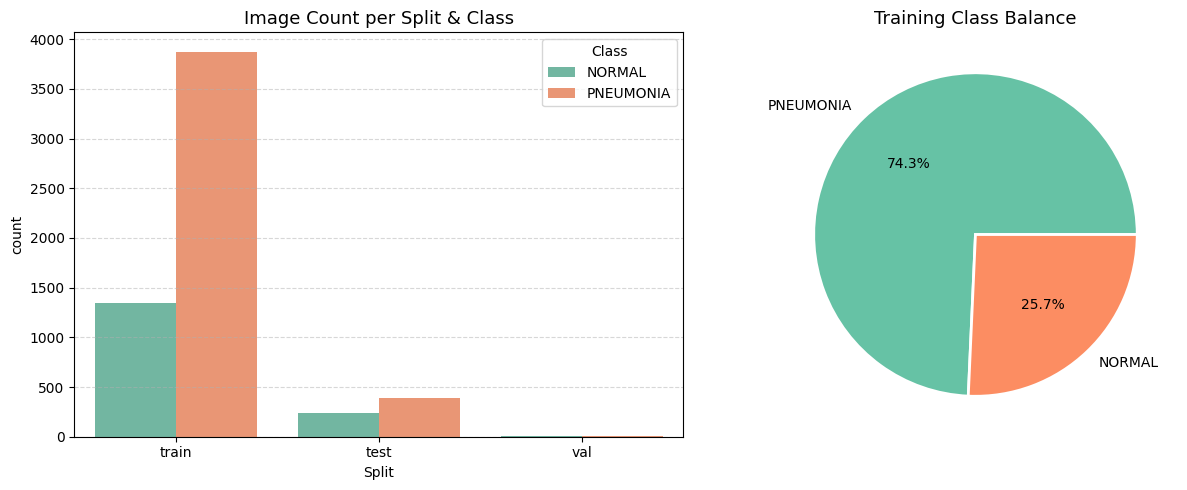

In [3]:
rows = []
for split in ['train', 'test', 'val']:
    for cls in CLASS_NAMES:
        d = os.path.join(BASE_DIR, split, cls)
        if not os.path.exists(d): continue
        for f in os.listdir(d):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                rows.append({'Split': split, 'Class': cls,
                             'Path': os.path.join(d, f)})
df = pd.DataFrame(rows)
print(pd.crosstab(df['Split'], df['Class'], margins=True, margins_name='Total'))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=df, x='Split', hue='Class', palette='Set2', ax=axes[0])
axes[0].set_title('Image Count per Split & Class', fontsize=13)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

counts = df[df['Split'] == 'train']['Class'].value_counts()
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#66c2a5', '#fc8d62'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Training Class Balance', fontsize=13)
plt.tight_layout(); plt.show()

## 3. Sample Images

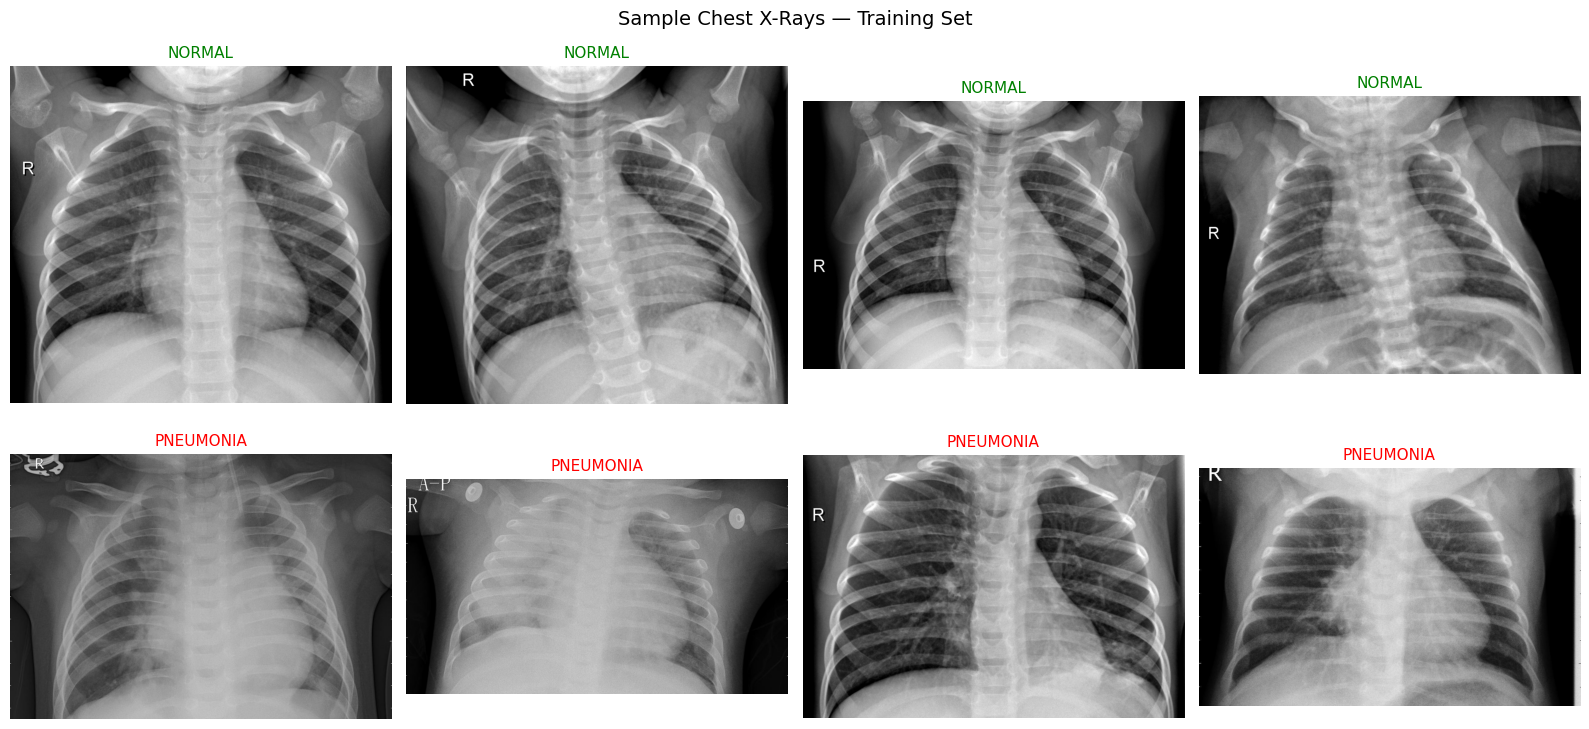

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Chest X-Rays — Training Set', fontsize=14)
for i, cls in enumerate(CLASS_NAMES):
    sub   = df[(df['Split'] == 'train') & (df['Class'] == cls)]
    paths = sub['Path'].sample(4, random_state=SEED).values
    for j, p in enumerate(paths):
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        axes[i, j].imshow(img)
        axes[i, j].set_title(cls, fontsize=11,
                              color='green' if cls == 'NORMAL' else 'red')
        axes[i, j].axis('off')
plt.tight_layout(); plt.show()

## 4. Custom Dataset with CLAHE

CLAHE (Contrast Limited Adaptive Histogram Equalization) X-ray image-এর
local contrast বাড়ায় — pneumonia-র subtle pattern ধরতে সাহায্য করে।

In [5]:
class XRayDataset(Dataset):
    """
    Custom Dataset:
      1. OpenCV দিয়ে image load (BGR → RGB)
      2. CLAHE on L-channel (LAB color space)
      3. Gaussian blur (mild denoising)
      4. PIL Image convert করে torchvision transform-এ পাঠায়
    """
    def __init__(self, root_dir, class_names, transform=None):
        self.transform    = transform
        self.class_names  = class_names
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        self.samples      = []
        self._clahe       = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

        for cls in class_names:
            d = os.path.join(root_dir, cls)
            if not os.path.exists(d): continue
            for f in os.listdir(d):
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append(
                        (os.path.join(d, f), self.class_to_idx[cls])
                    )

    def __len__(self):
        return len(self.samples)

    def _preprocess(self, path: str) -> Image.Image:
        # Step 1: Load & convert BGR → RGB
        img_rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        # Step 2: CLAHE on L-channel
        lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
        lab[:, :, 0] = self._clahe.apply(lab[:, :, 0])
        img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        # Step 3: Gaussian blur
        img = cv2.GaussianBlur(img, (3, 3), sigmaX=0.5)
        return Image.fromarray(img)   # PIL Image return

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        pil_img     = self._preprocess(path)
        if self.transform:
            pil_img = self.transform(pil_img)
        return pil_img, label

    @property
    def targets(self):
        return [s[1] for s in self.samples]


print('XRayDataset defined.')

XRayDataset defined.


## 5. Transforms

**DeiT input size: 224×224** (same as Swin)

⚠️ `RandomErasing` সর্বদা `ToTensor()` এবং `Normalize()`-এর **পরে** — PIL Image-এ `.shape` নেই।

In [6]:
IMG_SIZE      = 224
BATCH_SIZE    = 32
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Baseline (no augmentation) ────────────────────────────────────────────────
baseline_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Augmented (training only) ─────────────────────────────────────────────────
augmented_transform = T.Compose([
    T.Resize(256),
    T.RandomCrop(IMG_SIZE, padding=16, padding_mode='reflect'),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.1),
    T.RandomRotation(degrees=12),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05), shear=5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    T.RandomAutocontrast(p=0.3),
    T.ToTensor(),                                      # ← PIL → tensor
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.12),        # ← AFTER ToTensor (bug fix)
                   ratio=(0.3, 3.3), value=0),
])

# ── Test transform ────────────────────────────────────────────────────────────
test_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print('Transforms defined.')
print(f'  Baseline  : {len(baseline_transform.transforms)} steps')
print(f'  Augmented : {len(augmented_transform.transforms)} steps')

Transforms defined.
  Baseline  : 4 steps
  Augmented : 12 steps


## 6. Preprocessing Visualization

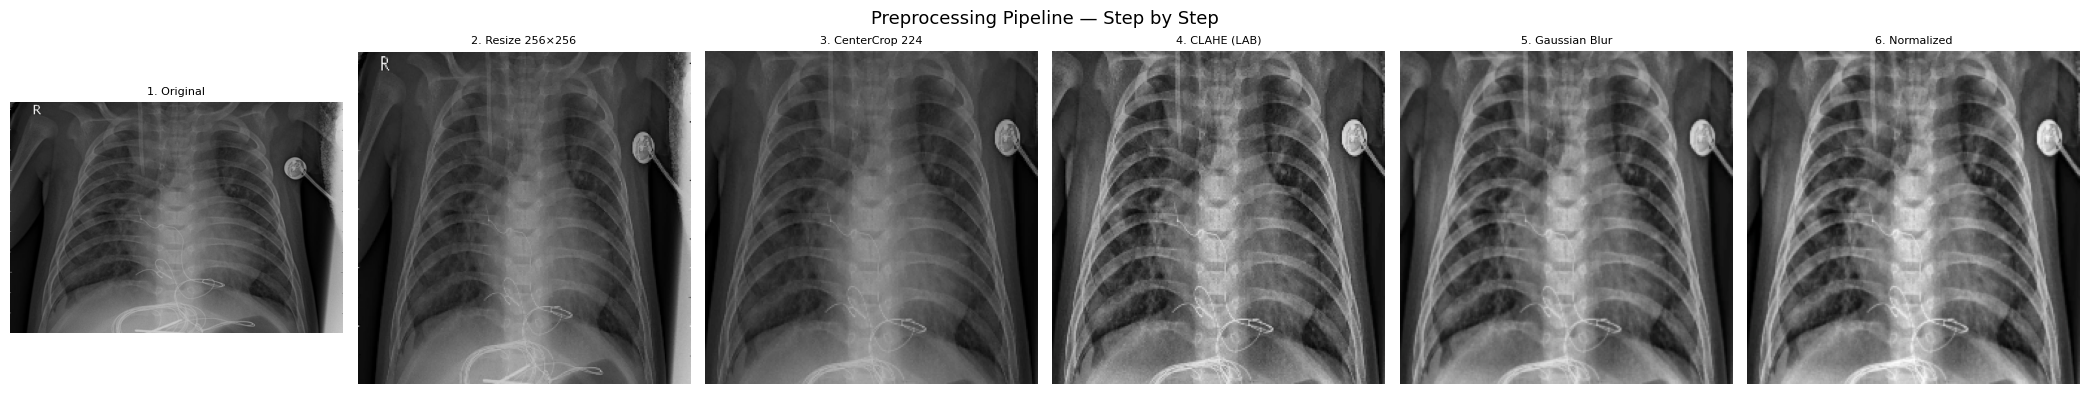

In [7]:
def show_preprocess_steps(img_path):
    bgr      = cv2.imread(img_path)
    original = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    resized  = cv2.resize(original, (256, 256))
    m        = (256 - 224) // 2
    cropped  = resized[m:m+224, m:m+224]

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab   = cv2.cvtColor(cropped, cv2.COLOR_RGB2LAB)
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    clahe_img    = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    blurred      = cv2.GaussianBlur(clahe_img, (3, 3), 0.5)
    norm         = blurred.astype(np.float32) / 255.0
    norm_vis     = ((norm - norm.min()) /
                    (norm.max() - norm.min()) * 255).astype(np.uint8)

    steps = [
        ('1. Original',       original),
        ('2. Resize 256×256', resized),
        ('3. CenterCrop 224', cropped),
        ('4. CLAHE (LAB)',    clahe_img),
        ('5. Gaussian Blur',  blurred),
        ('6. Normalized',     norm_vis),
    ]
    fig, axes = plt.subplots(1, 6, figsize=(21, 4))
    fig.suptitle('Preprocessing Pipeline — Step by Step', fontsize=13)
    for ax, (title, img) in zip(axes, steps):
        ax.imshow(img); ax.set_title(title, fontsize=8); ax.axis('off')
    plt.tight_layout(); plt.show()


sample_path = df[(df['Split'] == 'train') &
                 (df['Class'] == 'PNEUMONIA')]['Path'].iloc[0]
show_preprocess_steps(sample_path)

## 7. Augmentation Visualization

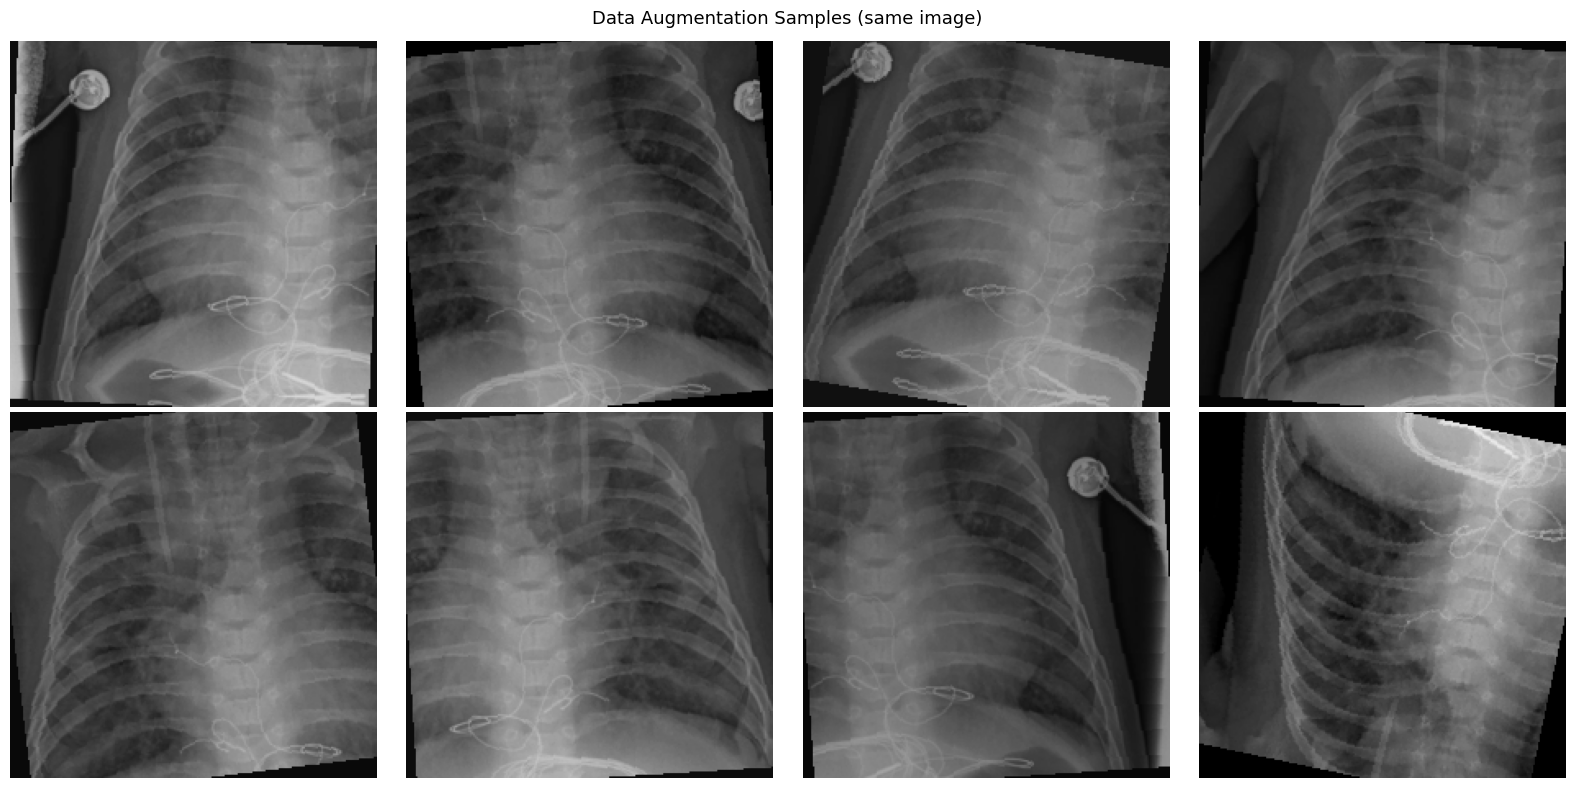

In [8]:
def show_augmentations(img_path, n=8):
    aug_display = T.Compose([
        T.Resize(256),
        T.RandomCrop(IMG_SIZE, padding=16, padding_mode='reflect'),
        T.RandomHorizontalFlip(0.5),
        T.RandomVerticalFlip(0.1),
        T.RandomRotation(12),
        T.ColorJitter(brightness=0.2, contrast=0.2),
    ])
    pil = Image.fromarray(
        cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    )
    fig, axes = plt.subplots(2, n // 2, figsize=(16, 8))
    fig.suptitle('Data Augmentation Samples (same image)', fontsize=13)
    for ax in axes.flat:
        ax.imshow(aug_display(pil)); ax.axis('off')
    plt.tight_layout(); plt.show()


show_augmentations(sample_path)

## 8. Downsampling — Class Balancing

PNEUMONIA (3875) >> NORMAL (1341) → imbalance overfitting এর কারণ।
Random undersampling দিয়ে majority class কমিয়ে আনা হয়।

In [9]:
def build_balanced_subset(dataset, seed=SEED):
    targets           = dataset.targets
    indices_by_class  = {}
    for idx, lbl in enumerate(targets):
        indices_by_class.setdefault(lbl, []).append(idx)

    min_count = min(len(v) for v in indices_by_class.values())
    rng       = random.Random(seed)

    balanced = []
    for cls, idxs in indices_by_class.items():
        balanced.extend(rng.sample(idxs, min_count))

    rng.shuffle(balanced)
    counts = Counter([targets[i] for i in balanced])
    print(f'  Balanced: {dict(counts)} | Total: {len(balanced)}')
    return Subset(dataset, balanced)


# Full datasets
full_train_base = XRayDataset(TRAIN_DIR, CLASS_NAMES, transform=baseline_transform)
full_train_aug  = XRayDataset(TRAIN_DIR, CLASS_NAMES, transform=augmented_transform)
test_ds         = XRayDataset(TEST_DIR,  CLASS_NAMES, transform=test_transform)

print(f'Full train: {len(full_train_base)} | Test: {len(test_ds)}')
print(f'Class distribution: {Counter(full_train_base.targets)}')

# Downsample
print('\nDownsampling...')
print('  Baseline:');  train_base = build_balanced_subset(full_train_base)
print('  Augmented:'); train_aug  = build_balanced_subset(full_train_aug)

# DataLoaders
def make_loader(ds, shuffle=True):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=4, pin_memory=True, persistent_workers=True)

train_loader_base = make_loader(train_base, shuffle=True)
train_loader_aug  = make_loader(train_aug,  shuffle=True)
test_loader       = make_loader(test_ds,    shuffle=False)

print(f'\nTrain base batches : {len(train_loader_base)}')
print(f'Train aug  batches : {len(train_loader_aug)}')
print(f'Test  batches      : {len(test_loader)}')

Full train: 5216 | Test: 624
Class distribution: Counter({1: 3875, 0: 1341})

Downsampling...
  Baseline:
  Balanced: {1: 1341, 0: 1341} | Total: 2682
  Augmented:
  Balanced: {1: 1341, 0: 1341} | Total: 2682

Train base batches : 84
Train aug  batches : 84
Test  batches      : 20


## 9. DeiT Model

### DeiT vs Swin পার্থক্য:
| বৈশিষ্ট্য | Swin | DeiT |
|-----------|------|------|
| Attention | Window-based (local) | Global (সব patch) |
| Patch size | 4×4 | 16×16 |
| Output | (B, 7, 7, 1024) spatial | (B, 197, 768) sequence |
| Special token | None | CLS token + Distillation token |
| Data need | বেশি | কম (Data-**efficient**) |

### DeiT-Base architecture:
```
Input 224×224×3
 → Patch Embed: 16×16 patches → 196 patches + 1 CLS + 1 Distill = 198 tokens
 → 12× Transformer Encoder Block
     (MultiHeadSelfAttention + MLP + LayerNorm)
 → CLS token → head Dropout → Linear(768→2)
```

In [10]:
def build_deit(num_classes=2, dropout=0.4):
    """
    DeiT-Base pretrained on ImageNet-1k.
    Head replaced: 768 → 512 → num_classes

    timm model name: 'deit_base_patch16_224'
    Pretrained weights: ImageNet-1k (Facebook Research)
    """
    class DeiTClassifier(nn.Module):
        def __init__(self):
            super().__init__()

            # DeiT-Base backbone (pretrained)
            # num_classes=0 removes the default head
            self.backbone = timm.create_model(
                'deit_base_patch16_224',
                pretrained  = True,
                num_classes = 0,       # remove default classifier
            )
            feat_dim = self.backbone.num_features   # 768 for DeiT-Base

            # Custom head with Dropout regularization
            self.head = nn.Sequential(
                nn.LayerNorm(feat_dim),
                nn.Dropout(p=dropout),
                nn.Linear(feat_dim, 512),
                nn.GELU(),
                nn.Dropout(p=dropout / 2),
                nn.Linear(512, num_classes),
            )

            # Head weight init
            for m in self.head.modules():
                if isinstance(m, nn.Linear):
                    nn.init.trunc_normal_(m.weight, std=0.02)
                    nn.init.zeros_(m.bias)

        def forward(self, x):
            # DeiT backbone returns CLS token: (B, 768)
            x = self.backbone(x)
            x = self.head(x)
            return x

        def freeze_backbone(self):
            for p in self.backbone.parameters():
                p.requires_grad = False

        def unfreeze_backbone(self):
            for p in self.backbone.parameters():
                p.requires_grad = True

    model     = DeiTClassifier()
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  DeiT-Base loaded')
    print(f'  Total params    : {total/1e6:.2f}M')
    print(f'  Trainable params: {trainable/1e6:.2f}M')
    return model


# Quick test
print('Testing model build...')
test_model = build_deit()
dummy = torch.zeros(2, 3, 224, 224)
with torch.no_grad():
    out = test_model(dummy)
print(f'  Forward pass: input={tuple(dummy.shape)} → output={tuple(out.shape)}')
del test_model

Testing model build...


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

  DeiT-Base loaded
  Total params    : 86.19M
  Trainable params: 86.19M
  Forward pass: input=(2, 3, 224, 224) → output=(2, 2)


## 10. Training Utilities

### Anti-overfitting strategy:
- **Phase 1** (epoch 1-3): Backbone frozen, শুধু head train হয়
- **Phase 2** (epoch 4+): Full model train — backbone lr/10, head lr
- **Label Smoothing**: Hard 0/1 target মুখস্থ করা কমায়
- **Grad Clipping**: Exploding gradient রোধ করে

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=DEVICE.type == 'cuda'):
            out  = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer); scaler.update()

        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out         = model(imgs)
        loss        = criterion(out, labels)
        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total


def run_training(label, train_loader,
                 epochs=15, lr=5e-5, patience=5,
                 freeze_epochs=3, weight_decay=1e-3,
                 label_smoothing=0.1, dropout=0.4):

    print(f'\n{"="*60}')
    print(f'  Training: {label}')
    print(f'{"="*60}')

    model     = build_deit(dropout=dropout).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    scaler    = torch.amp.GradScaler('cuda', enabled=DEVICE.type == 'cuda')

    # Phase 1: freeze backbone
    model.freeze_backbone()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=lr * 0.01
    )

    history    = {'train_loss': [], 'val_loss': [],
                  'train_acc': [],  'val_acc': [],
                  'epoch_times': []}
    best_acc   = 0.0
    best_wts   = None
    no_improve = 0
    t_total    = time.time()

    for epoch in range(1, epochs + 1):

        # Phase 2: unfreeze backbone after freeze_epochs
        if epoch == freeze_epochs + 1:
            print(f'  → Epoch {epoch}: Unfreeze backbone (backbone lr={lr/10:.2e})')
            model.unfreeze_backbone()
            optimizer = optim.AdamW([
                {'params': model.backbone.parameters(), 'lr': lr / 10},
                {'params': model.head.parameters(),     'lr': lr},
            ], weight_decay=weight_decay)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=epochs - freeze_epochs, eta_min=lr * 0.01
            )

        t_ep = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader,
                                          criterion, optimizer, scaler)
        vl_loss, vl_acc = evaluate(model, test_loader, criterion)
        scheduler.step()
        ep_t = time.time() - t_ep

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['epoch_times'].append(ep_t)

        gap = tr_acc - vl_acc
        print(f'  Ep {epoch:02d}/{epochs} | '
              f'tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} | '
              f'vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f} | '
              f'gap={gap:+.3f} | {ep_t:.1f}s')

        if vl_acc > best_acc:
            best_acc   = vl_acc
            best_wts   = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stopping at epoch {epoch}')
                break

    total_t = time.time() - t_total
    history['total_time'] = round(total_t, 1)
    history['avg_epoch']  = round(np.mean(history['epoch_times']), 1)
    model.load_state_dict(best_wts)
    torch.save(model.state_dict(), f'/kaggle/working/{label}.pth')
    print(f'  Best val acc: {best_acc:.4f} | Total: {total_t:.1f}s')
    return model, history


print('Training functions ready.')

Training functions ready.


## 11. Evaluation & Plot Utilities

In [12]:
@torch.no_grad()
def evaluate_model(model, loader, label):
    model.eval()
    all_preds, all_true = [], []
    for imgs, labels in loader:
        out = model(imgs.to(DEVICE))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_true.extend(labels.numpy())

    acc  = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, average='weighted', zero_division=0)
    rec  = recall_score(all_true, all_preds, average='weighted', zero_division=0)
    f1   = f1_score(all_true, all_preds, average='weighted', zero_division=0)
    cm   = confusion_matrix(all_true, all_preds)

    tmp = f'/tmp/{label}.pth'
    torch.save(model.state_dict(), tmp)
    size_mb = round(os.path.getsize(tmp) / 1024 ** 2, 2)
    total_p = sum(p.numel() for p in model.parameters())
    train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)

    metrics = {
        'Accuracy'              : round(acc,  4),
        'Precision'             : round(prec, 4),
        'Recall'                : round(rec,  4),
        'F1 Score'              : round(f1,   4),
        'Confusion Matrix'      : cm,
        'Model Size (MB)'       : size_mb,
        'Total Params (M)'      : round(total_p / 1e6, 2),
        'Trainable Params (M)'  : round(train_p / 1e6, 2),
    }

    print(f'\n=== {label} ===')
    for k, v in metrics.items():
        if k != 'Confusion Matrix': print(f'  {k}: {v}')
    print()
    print(classification_report(all_true, all_preds, target_names=CLASS_NAMES))
    return metrics


def plot_history(history, label):
    eps    = range(1, len(history['train_loss']) + 1)
    tr_acc = np.array(history['train_acc'])
    vl_acc = np.array(history['val_acc'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training History — {label}', fontsize=13)

    axes[0].plot(eps, history['train_loss'], 'b-o', ms=4, label='Train Loss')
    axes[0].plot(eps, history['val_loss'],   'r-s', ms=4, label='Val Loss')
    axes[0].set_title('Loss vs Epochs')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.4)

    axes[1].plot(eps, tr_acc, 'b-o', ms=4, label='Train Acc')
    axes[1].plot(eps, vl_acc, 'r-s', ms=4, label='Val Acc')
    axes[1].fill_between(eps, vl_acc, tr_acc,
                          where=(tr_acc > vl_acc),
                          alpha=0.15, color='red', label='Overfitting gap')
    axes[1].set_title('Accuracy vs Epochs')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.4)

    plt.tight_layout(); plt.show()


def plot_cm(cm, label):
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {label}', fontsize=11)
    plt.tight_layout(); plt.show()


print('Evaluation utilities ready.')

Evaluation utilities ready.


---
# Setup 1: DeiT — Baseline Preprocessing (No Augmentation)

In [13]:
model_base, hist_base = run_training(
    label         = 'DeiT_Baseline',
    train_loader  = train_loader_base,
    epochs        = 15,
    lr            = 5e-5,
    patience      = 5,
    freeze_epochs = 3,
    weight_decay  = 1e-3,
    label_smoothing = 0.1,
    dropout       = 0.4,
)


  Training: DeiT_Baseline


  DeiT-Base loaded
  Total params    : 86.19M
  Trainable params: 86.19M
  Ep 01/15 | tr_loss=0.4948 tr_acc=0.8434 | vl_loss=0.4584 vl_acc=0.8381 | gap=+0.005 | 103.9s
  Ep 02/15 | tr_loss=0.3459 tr_acc=0.9254 | vl_loss=0.4437 vl_acc=0.8446 | gap=+0.081 | 99.5s
  Ep 03/15 | tr_loss=0.3243 tr_acc=0.9333 | vl_loss=0.4383 vl_acc=0.8526 | gap=+0.081 | 100.8s
  → Epoch 4: Unfreeze backbone (backbone lr=5.00e-06)
  Ep 04/15 | tr_loss=0.2936 tr_acc=0.9549 | vl_loss=0.4063 vl_acc=0.8846 | gap=+0.070 | 105.5s
  Ep 05/15 | tr_loss=0.2531 tr_acc=0.9791 | vl_loss=0.3880 vl_acc=0.8990 | gap=+0.080 | 105.7s
  Ep 06/15 | tr_loss=0.2305 tr_acc=0.9896 | vl_loss=0.3976 vl_acc=0.8926 | gap=+0.097 | 104.6s
  Ep 07/15 | tr_loss=0.2169 tr_acc=0.9978 | vl_loss=0.4250 vl_acc=0.8846 | gap=+0.113 | 104.8s
  Ep 08/15 | tr_loss=0.2098 tr_acc=0.9996 | vl_loss=0.4217 vl_acc=0.8846 | gap=+0.115 | 106.0s
  Ep 09/15 | tr_loss=0.2067 tr_acc=1.0000 | vl_loss=0.4322 vl_acc=0.8750 | gap=+0.125 | 105.0s
  Ep 10/15 | tr_los

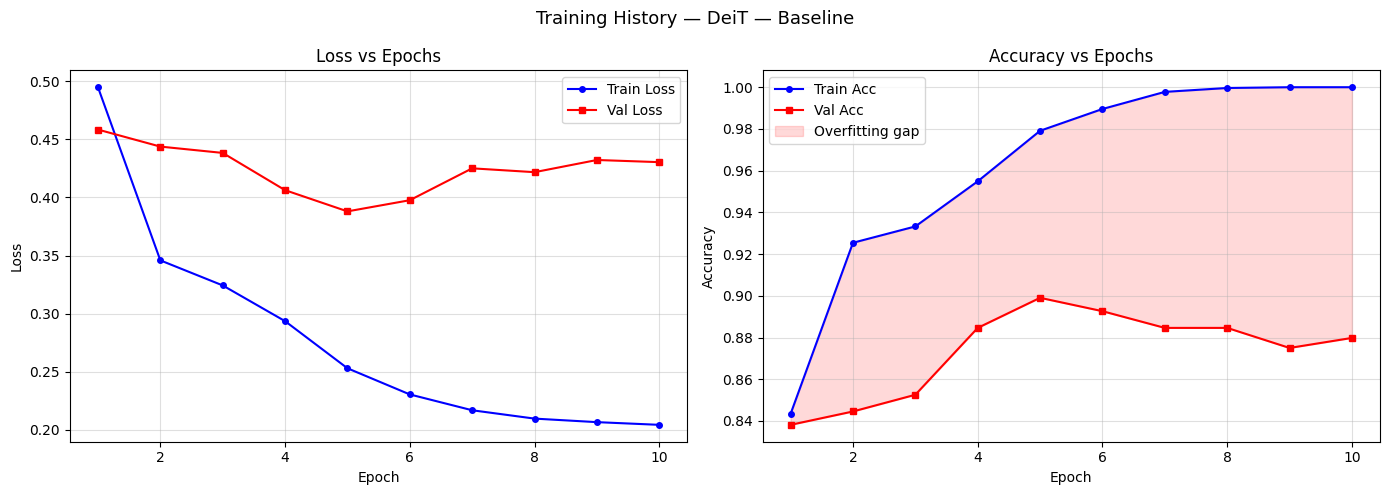


=== DeiT Baseline ===
  Accuracy: 0.899
  Precision: 0.9061
  Recall: 0.899
  F1 Score: 0.8961
  Model Size (MB): 328.87
  Total Params (M): 86.19
  Trainable Params (M): 86.19

              precision    recall  f1-score   support

      NORMAL       0.96      0.76      0.85       234
   PNEUMONIA       0.87      0.98      0.92       390

    accuracy                           0.90       624
   macro avg       0.92      0.87      0.89       624
weighted avg       0.91      0.90      0.90       624



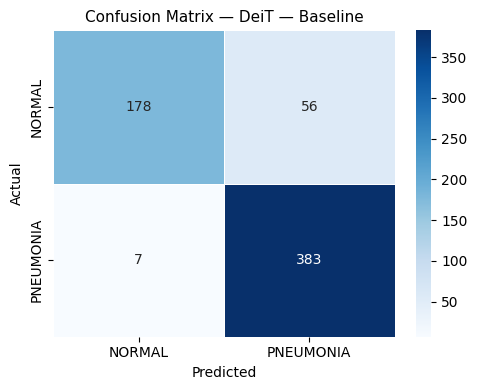

In [14]:
plot_history(hist_base, 'DeiT — Baseline')
m_base = evaluate_model(model_base, test_loader, 'DeiT Baseline')
m_base['Total Time (s)'] = hist_base['total_time']
m_base['Avg Epoch (s)']  = hist_base['avg_epoch']
plot_cm(m_base['Confusion Matrix'], 'DeiT — Baseline')

---
# Setup 2: DeiT — Augmented Preprocessing

In [15]:
model_aug, hist_aug = run_training(
    label         = 'DeiT_Augmented',
    train_loader  = train_loader_aug,
    epochs        = 15,
    lr            = 5e-5,
    patience      = 5,
    freeze_epochs = 3,
    weight_decay  = 1e-3,
    label_smoothing = 0.1,
    dropout       = 0.4,
)


  Training: DeiT_Augmented
  DeiT-Base loaded
  Total params    : 86.19M
  Trainable params: 86.19M
  Ep 01/15 | tr_loss=0.5663 tr_acc=0.7726 | vl_loss=0.6996 vl_acc=0.5705 | gap=+0.202 | 111.1s
  Ep 02/15 | tr_loss=0.4354 tr_acc=0.8643 | vl_loss=0.6036 vl_acc=0.7292 | gap=+0.135 | 109.7s
  Ep 03/15 | tr_loss=0.4051 tr_acc=0.8747 | vl_loss=0.5267 vl_acc=0.7901 | gap=+0.085 | 109.1s
  → Epoch 4: Unfreeze backbone (backbone lr=5.00e-06)
  Ep 04/15 | tr_loss=0.3398 tr_acc=0.9183 | vl_loss=0.4394 vl_acc=0.8301 | gap=+0.088 | 113.2s
  Ep 05/15 | tr_loss=0.2996 tr_acc=0.9478 | vl_loss=0.3908 vl_acc=0.8750 | gap=+0.073 | 114.4s
  Ep 06/15 | tr_loss=0.2902 tr_acc=0.9556 | vl_loss=0.4096 vl_acc=0.8574 | gap=+0.098 | 115.5s
  Ep 07/15 | tr_loss=0.2857 tr_acc=0.9523 | vl_loss=0.3586 vl_acc=0.9054 | gap=+0.047 | 114.7s
  Ep 08/15 | tr_loss=0.2791 tr_acc=0.9623 | vl_loss=0.3855 vl_acc=0.8846 | gap=+0.078 | 115.0s
  Ep 09/15 | tr_loss=0.2718 tr_acc=0.9612 | vl_loss=0.3562 vl_acc=0.9022 | gap=+0.059

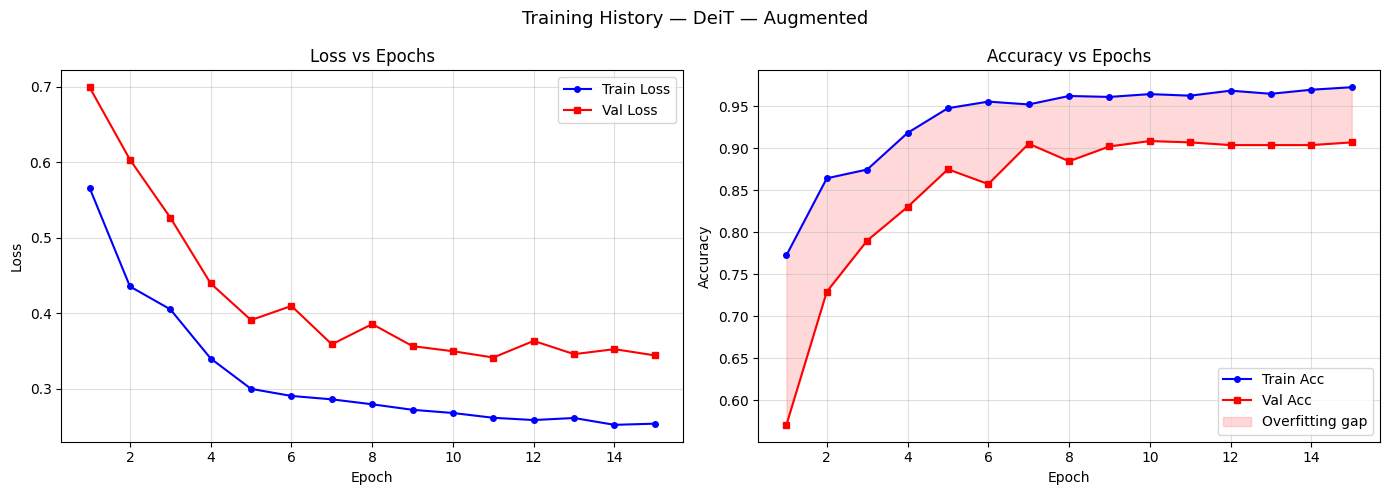


=== DeiT Augmented ===
  Accuracy: 0.9087
  Precision: 0.9107
  Recall: 0.9087
  F1 Score: 0.9072
  Model Size (MB): 328.87
  Total Params (M): 86.19
  Trainable Params (M): 86.19

              precision    recall  f1-score   support

      NORMAL       0.94      0.81      0.87       234
   PNEUMONIA       0.90      0.97      0.93       390

    accuracy                           0.91       624
   macro avg       0.92      0.89      0.90       624
weighted avg       0.91      0.91      0.91       624



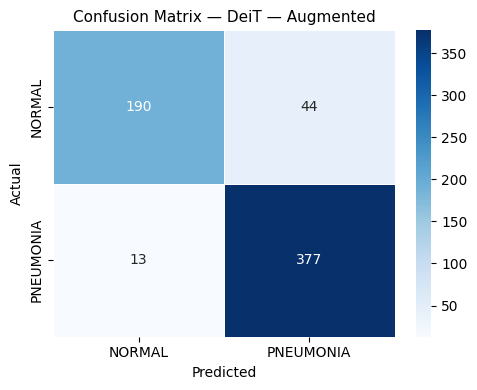

In [17]:
plot_history(hist_aug, 'DeiT — Augmented')
m_aug = evaluate_model(model_aug, test_loader, 'DeiT Augmented')
m_aug['Total Time (s)'] = hist_aug['total_time']
m_aug['Avg Epoch (s)']  = hist_aug['avg_epoch']
plot_cm(m_aug['Confusion Matrix'], 'DeiT — Augmented')

---
## 12. Results Comparison

In [18]:
results = [
    ('Baseline',  m_base),
    ('Augmented', m_aug),
]

rows = []
for setup, m in results:
    rows.append({
        'Model'         : 'DeiT-Base',
        'Setup'         : setup,
        'Accuracy'      : m['Accuracy'],
        'Precision'     : m['Precision'],
        'Recall'        : m['Recall'],
        'F1 Score'      : m['F1 Score'],
        'Size (MB)'     : m['Model Size (MB)'],
        'Params (M)'    : m['Total Params (M)'],
        'Total Time (s)': m['Total Time (s)'],
        'Avg Epoch (s)' : m['Avg Epoch (s)'],
    })

res_df = pd.DataFrame(rows)
print('\n======= DeiT RESULTS =======')
print(res_df.to_string(index=False))
res_df.to_csv('/kaggle/working/deit_results.csv', index=False)
print('Saved to /kaggle/working/deit_results.csv')


======= DeiT RESULTS =======
    Model     Setup  Accuracy  Precision  Recall  F1 Score  Size (MB)  Params (M)  Total Time (s)  Avg Epoch (s)
DeiT-Base  Baseline    0.8990     0.9061  0.8990    0.8961     328.87       86.19          1041.4          104.1
DeiT-Base Augmented    0.9087     0.9107  0.9087    0.9072     328.87       86.19          1697.8          113.2
Saved to /kaggle/working/deit_results.csv


## 13. Comparison Plots

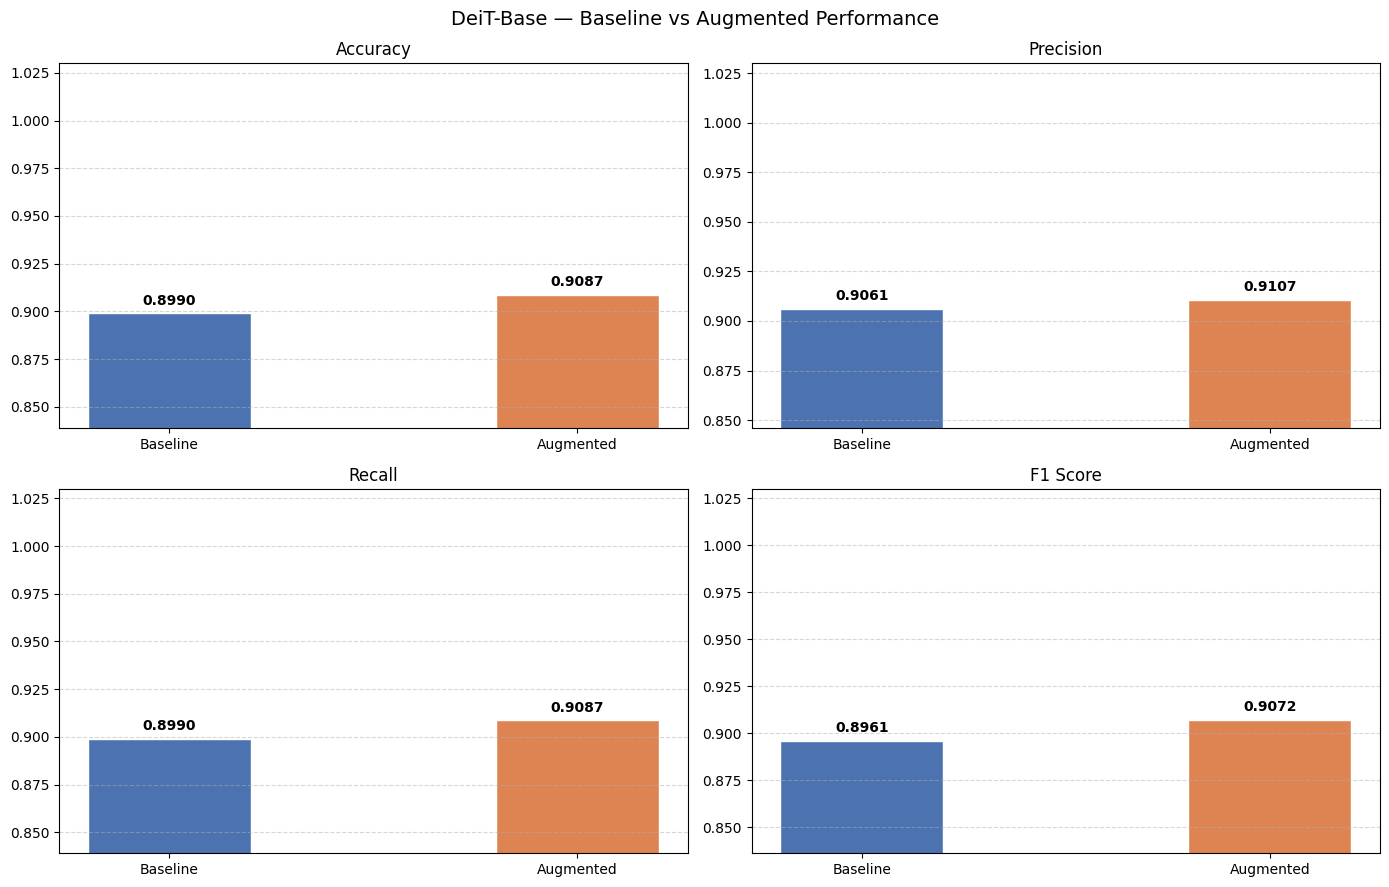

In [19]:
# ── Bar chart: Baseline vs Augmented ─────────────────────────────────────────
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors       = ['#4C72B0', '#DD8452']
labels       = ['Baseline', 'Augmented']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('DeiT-Base — Baseline vs Augmented Performance', fontsize=14)

for ax, metric in zip(axes.flat, metrics_list):
    vals = res_df[metric].values
    bars = ax.bar(labels, vals, color=colors, edgecolor='white', width=0.4)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(max(0, vals.min() - 0.06), 1.03)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{bar.get_height():.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout(); plt.show()

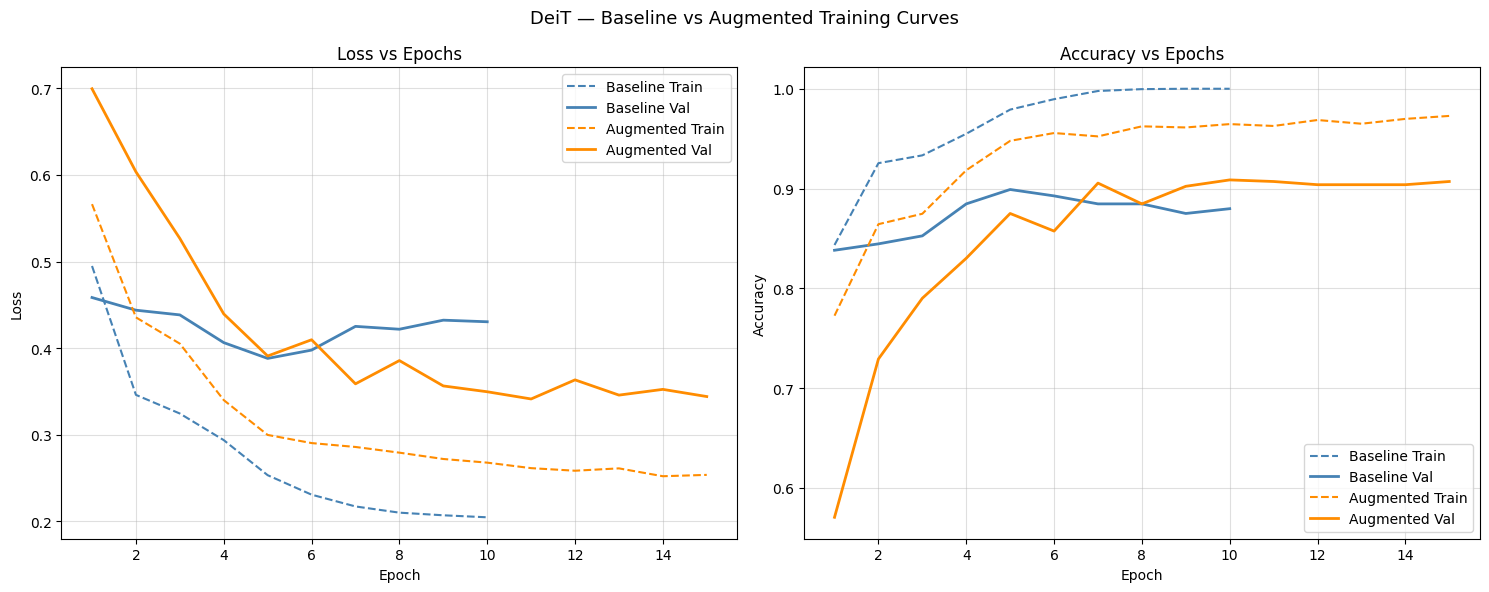

In [20]:
# ── Overlay: Baseline vs Augmented — loss & accuracy ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('DeiT — Baseline vs Augmented Training Curves', fontsize=13)

for hist, lbl, col in [
    (hist_base, 'Baseline',  'steelblue'),
    (hist_aug,  'Augmented', 'darkorange')
]:
    ep = range(1, len(hist['train_loss']) + 1)
    axes[0].plot(ep, hist['train_loss'], color=col, ls='--', lw=1.5,
                 label=f'{lbl} Train')
    axes[0].plot(ep, hist['val_loss'],   color=col, ls='-',  lw=2.0,
                 label=f'{lbl} Val')
    axes[1].plot(ep, hist['train_acc'],  color=col, ls='--', lw=1.5,
                 label=f'{lbl} Train')
    axes[1].plot(ep, hist['val_acc'],    color=col, ls='-',  lw=2.0,
                 label=f'{lbl} Val')

axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].set_title('Accuracy vs Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout(); plt.show()

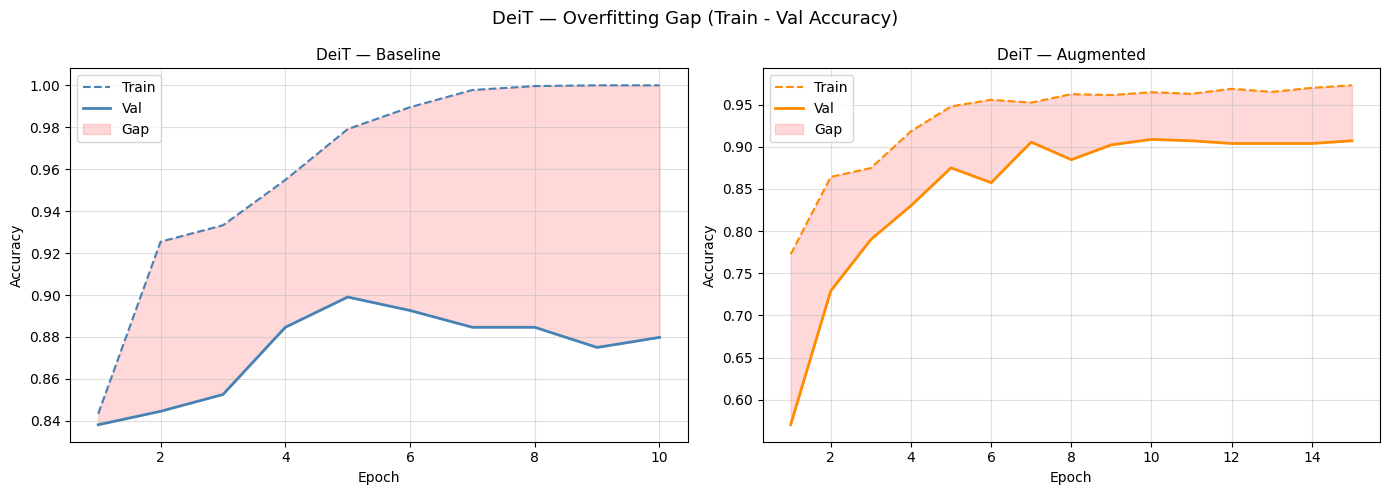

In [21]:
# ── Overfitting gap ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DeiT — Overfitting Gap (Train - Val Accuracy)', fontsize=13)

for ax, hist, lbl, col in [
    (axes[0], hist_base, 'Baseline',  'steelblue'),
    (axes[1], hist_aug,  'Augmented', 'darkorange'),
]:
    ep  = list(range(1, len(hist['train_acc']) + 1))
    tr  = np.array(hist['train_acc'])
    vl  = np.array(hist['val_acc'])
    ax.plot(ep, tr, color=col, ls='--', lw=1.5, label='Train')
    ax.plot(ep, vl, color=col, ls='-',  lw=2.0, label='Val')
    ax.fill_between(ep, vl, tr, where=(tr > vl),
                    alpha=0.15, color='red', label='Gap')
    ax.set_title(f'DeiT — {lbl}', fontsize=11)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(alpha=0.4)

plt.tight_layout(); plt.show()

## 14. Final Summary

In [22]:
print('=' * 60)
print('DeiT-Base — FINAL RESULTS SUMMARY')
print('=' * 60)
print(res_df[['Model', 'Setup', 'Accuracy', 'Precision',
              'Recall', 'F1 Score', 'Params (M)',
              'Size (MB)', 'Total Time (s)']].to_string(index=False))

best = res_df.loc[res_df['Accuracy'].idxmax()]
print(f'\n✅  Best setup    : {best["Setup"]}')
print(f'    Accuracy     : {best["Accuracy"]}')
print(f'    F1 Score     : {best["F1 Score"]}')
print(f'    Total Time   : {best["Total Time (s)"]}s')

aug_gain = m_aug['Accuracy'] - m_base['Accuracy']
print(f'\n📊  Augmentation gain: {aug_gain:+.4f} accuracy')

DeiT-Base — FINAL RESULTS SUMMARY
    Model     Setup  Accuracy  Precision  Recall  F1 Score  Params (M)  Size (MB)  Total Time (s)
DeiT-Base  Baseline    0.8990     0.9061  0.8990    0.8961       86.19     328.87          1041.4
DeiT-Base Augmented    0.9087     0.9107  0.9087    0.9072       86.19     328.87          1697.8

✅  Best setup    : Augmented
    Accuracy     : 0.9087
    F1 Score     : 0.9072
    Total Time   : 1697.8s

📊  Augmentation gain: +0.0097 accuracy


---
# Setup 3: DeiT + SE Block — Augmented

In [24]:
# ── SE Block ──────────────────────────────────────────────────────────────────
class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation Block.
    Matches tfm.vision.layers.SqueezeExcitation parameters:
      in_filters, se_ratio, divisible_by,
      activation=relu, gating_activation=sigmoid,
      round_down_protect=True

    Forward:
      x (B, C)  ← DeiT CLS token output is 1D, no spatial dims
       → FC1(C → C*se_ratio, relu)    [Excitation reduce]
       → FC2(C*se_ratio → C, sigmoid) [Excitation gating]
       → x * scale                    [Recalibrate]
    """
    def __init__(self, in_filters, se_ratio=0.25,
                 divisible_by=8, round_down_protect=True):
        super().__init__()

        num_reduced = max(1, int(in_filters * se_ratio))
        if round_down_protect:
            if num_reduced < in_filters * se_ratio * 0.9:
                num_reduced = math.ceil(
                    in_filters * se_ratio / divisible_by) * divisible_by
        num_reduced = math.ceil(num_reduced / divisible_by) * divisible_by

        # NOTE: DeiT output is (B, 768) — no spatial dims
        # So we use Linear instead of Conv2d
        self.fc1  = nn.Linear(in_filters, num_reduced, bias=True)
        self.act  = nn.ReLU(inplace=True)
        self.fc2  = nn.Linear(num_reduced, in_filters, bias=True)
        self.gate = nn.Sigmoid()

        nn.init.xavier_uniform_(self.fc1.weight); nn.init.zeros_(self.fc1.bias)
        nn.init.xavier_uniform_(self.fc2.weight); nn.init.zeros_(self.fc2.bias)

    def forward(self, x):              # x: (B, C)
        scale = self.act(self.fc1(x))  # (B, C_r)
        scale = self.gate(self.fc2(scale))  # (B, C) — sigmoid gating
        return x * scale               # (B, C) recalibrated


# Unit test
dummy = torch.zeros(2, 768)
se    = SEBlock(in_filters=768, se_ratio=0.25)
out   = se(dummy)
print(f'SE unit test — input: {tuple(dummy.shape)}, output: {tuple(out.shape)}')
print(f'SE params: {sum(p.numel() for p in se.parameters()):,}')

SE unit test — input: (2, 768), output: (2, 768)
SE params: 295,872


In [25]:
# ── DeiT + SE Model ───────────────────────────────────────────────────────────
def build_deit_se(num_classes=2, dropout=0.4):
    """
    DeiT-Base + SE Block + classification head.

    Architecture:
        Input (B, 3, 224, 224)
         → DeiT-Base backbone (pretrained ImageNet)
            → CLS token: (B, 768)
         ↓ [SE Block]
         → SEBlock(768, se_ratio=0.25)
            FC1: 768 → 192 (relu)
            FC2: 192 → 768 (sigmoid gating)
            x * scale → (B, 768) recalibrated
         ↓
         → LayerNorm → Dropout(0.4)
         → Linear(768→512) → GELU
         → Dropout(0.2)
         → Linear(512→num_classes)
    """
    class DeiTSE(nn.Module):
        def __init__(self):
            super().__init__()
            self.backbone = timm.create_model(
                'deit_base_patch16_224',
                pretrained  = True,
                num_classes = 0,
            )
            feat_dim = self.backbone.num_features   # 768

            self.se = SEBlock(
                in_filters       = feat_dim,
                se_ratio         = 0.25,
                divisible_by     = 8,
                round_down_protect = True
            )

            self.head = nn.Sequential(
                nn.LayerNorm(feat_dim),
                nn.Dropout(p=dropout),
                nn.Linear(feat_dim, 512),
                nn.GELU(),
                nn.Dropout(p=dropout / 2),
                nn.Linear(512, num_classes),
            )
            for m in self.head.modules():
                if isinstance(m, nn.Linear):
                    nn.init.trunc_normal_(m.weight, std=0.02)
                    nn.init.zeros_(m.bias)

        def forward(self, x):
            x = self.backbone(x)   # (B, 768) — CLS token
            x = self.se(x)         # (B, 768) — SE recalibrated
            x = self.head(x)       # (B, num_classes)
            return x

        def freeze_backbone(self):
            for p in self.backbone.parameters():
                p.requires_grad = False

        def unfreeze_backbone(self):
            for p in self.backbone.parameters():
                p.requires_grad = True

    model     = DeiTSE()
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'DeiT + SE loaded')
    print(f'  Total params    : {total/1e6:.2f}M')
    print(f'  Trainable params: {trainable/1e6:.2f}M')
    return model


# Quick forward test
print('\nTesting DeiT+SE forward pass...')
_m = build_deit_se()
with torch.no_grad():
    _out = _m(torch.zeros(2, 3, 224, 224))
print(f'Output shape: {tuple(_out.shape)}')
del _m


Testing DeiT+SE forward pass...
DeiT + SE loaded
  Total params    : 86.49M
  Trainable params: 86.49M
Output shape: (2, 2)


In [26]:
# ── Training ──────────────────────────────────────────────────────────────────
def run_training_se(label, train_loader,
                    epochs=15, lr=5e-5, patience=5,
                    freeze_epochs=3, weight_decay=1e-3,
                    label_smoothing=0.1, dropout=0.4):

    print(f'\n{"="*60}')
    print(f'  Training: {label}')
    print(f'{"="*60}')

    model     = build_deit_se(dropout=dropout).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    scaler    = torch.amp.GradScaler('cuda', enabled=DEVICE.type == 'cuda')

    # Phase 1: freeze backbone
    model.freeze_backbone()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=lr * 0.01
    )

    history    = {'train_loss': [], 'val_loss': [],
                  'train_acc': [],  'val_acc': [],
                  'epoch_times': []}
    best_acc   = 0.0
    best_wts   = None
    no_improve = 0
    t_total    = time.time()

    for epoch in range(1, epochs + 1):

        # Phase 2: unfreeze after freeze_epochs
        if epoch == freeze_epochs + 1:
            print(f'  → Epoch {epoch}: Unfreeze backbone (lr={lr/10:.2e})')
            model.unfreeze_backbone()
            optimizer = optim.AdamW([
                {'params': model.backbone.parameters(), 'lr': lr / 10},
                {'params': model.se.parameters(),       'lr': lr},
                {'params': model.head.parameters(),     'lr': lr},
            ], weight_decay=weight_decay)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=epochs - freeze_epochs, eta_min=lr * 0.01
            )

        t_ep = time.time()

        # Train
        model.train()
        t_loss = t_correct = t_total_n = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=DEVICE.type == 'cuda'):
                out  = model(imgs)
                loss = criterion(out, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer); scaler.update()
            t_loss    += loss.item()
            t_correct += (out.argmax(1) == labels).sum().item()
            t_total_n += labels.size(0)
        tr_loss = t_loss / len(train_loader)
        tr_acc  = t_correct / t_total_n

        # Validate
        model.eval()
        v_loss = v_correct = v_total_n = 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out   = model(imgs)
                loss  = criterion(out, labels)
                v_loss    += loss.item()
                v_correct += (out.argmax(1) == labels).sum().item()
                v_total_n += labels.size(0)
        vl_loss = v_loss / len(test_loader)
        vl_acc  = v_correct / v_total_n

        scheduler.step()
        ep_t = time.time() - t_ep

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['epoch_times'].append(ep_t)

        gap = tr_acc - vl_acc
        print(f'  Ep {epoch:02d}/{epochs} | '
              f'tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} | '
              f'vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f} | '
              f'gap={gap:+.3f} | {ep_t:.1f}s')

        if vl_acc > best_acc:
            best_acc   = vl_acc
            best_wts   = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stopping at epoch {epoch}')
                break

    total_t = time.time() - t_total
    history['total_time'] = round(total_t, 1)
    history['avg_epoch']  = round(np.mean(history['epoch_times']), 1)
    model.load_state_dict(best_wts)
    torch.save(model.state_dict(), f'/kaggle/working/{label}.pth')
    print(f'  Best val acc: {best_acc:.4f} | Total: {total_t:.1f}s')
    return model, history


# ── Run ───────────────────────────────────────────────────────────────────────
model_se_aug, hist_se_aug = run_training_se(
    label           = 'DeiT_SE_Augmented',
    train_loader    = train_loader_aug,
    epochs          = 15,
    lr              = 5e-5,
    patience        = 5,
    freeze_epochs   = 3,
    weight_decay    = 1e-3,
    label_smoothing = 0.1,
    dropout         = 0.4,
)


  Training: DeiT_SE_Augmented
DeiT + SE loaded
  Total params    : 86.49M
  Trainable params: 86.49M
  Ep 01/15 | tr_loss=0.5516 tr_acc=0.7711 | vl_loss=0.6052 vl_acc=0.7500 | gap=+0.021 | 110.2s
  Ep 02/15 | tr_loss=0.4310 tr_acc=0.8598 | vl_loss=0.5244 vl_acc=0.8141 | gap=+0.046 | 110.1s
  Ep 03/15 | tr_loss=0.3836 tr_acc=0.8852 | vl_loss=0.4945 vl_acc=0.8173 | gap=+0.068 | 109.7s
  → Epoch 4: Unfreeze backbone (lr=5.00e-06)
  Ep 04/15 | tr_loss=0.3414 tr_acc=0.9217 | vl_loss=0.4149 vl_acc=0.8702 | gap=+0.052 | 114.4s
  Ep 05/15 | tr_loss=0.3036 tr_acc=0.9437 | vl_loss=0.4096 vl_acc=0.8558 | gap=+0.088 | 114.3s
  Ep 06/15 | tr_loss=0.2911 tr_acc=0.9497 | vl_loss=0.3852 vl_acc=0.8878 | gap=+0.062 | 114.2s
  Ep 07/15 | tr_loss=0.2804 tr_acc=0.9594 | vl_loss=0.4343 vl_acc=0.8397 | gap=+0.120 | 113.7s
  Ep 08/15 | tr_loss=0.2674 tr_acc=0.9627 | vl_loss=0.3637 vl_acc=0.8990 | gap=+0.064 | 113.6s
  Ep 09/15 | tr_loss=0.2615 tr_acc=0.9687 | vl_loss=0.3626 vl_acc=0.9006 | gap=+0.068 | 113.3

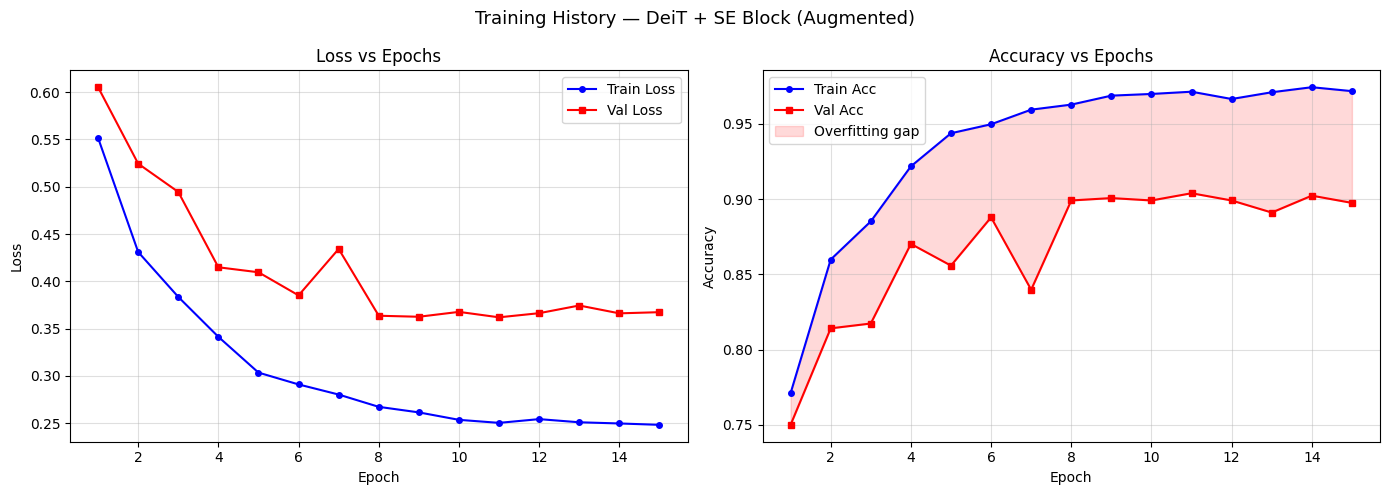

In [27]:
# ── Plot history ──────────────────────────────────────────────────────────────
eps    = range(1, len(hist_se_aug['train_loss']) + 1)
tr_acc = np.array(hist_se_aug['train_acc'])
vl_acc = np.array(hist_se_aug['val_acc'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — DeiT + SE Block (Augmented)', fontsize=13)

axes[0].plot(eps, hist_se_aug['train_loss'], 'b-o', ms=4, label='Train Loss')
axes[0].plot(eps, hist_se_aug['val_loss'],   'r-s', ms=4, label='Val Loss')
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].plot(eps, tr_acc, 'b-o', ms=4, label='Train Acc')
axes[1].plot(eps, vl_acc, 'r-s', ms=4, label='Val Acc')
axes[1].fill_between(eps, vl_acc, tr_acc,
                      where=(tr_acc > vl_acc),
                      alpha=0.15, color='red', label='Overfitting gap')
axes[1].set_title('Accuracy vs Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout(); plt.show()

In [28]:
# ── Evaluate ──────────────────────────────────────────────────────────────────
model_se_aug.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        out = model_se_aug(imgs.to(DEVICE))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_true.extend(labels.numpy())

acc  = accuracy_score(all_true, all_preds)
prec = precision_score(all_true, all_preds, average='weighted', zero_division=0)
rec  = recall_score(all_true, all_preds, average='weighted', zero_division=0)
f1   = f1_score(all_true, all_preds, average='weighted', zero_division=0)
cm   = confusion_matrix(all_true, all_preds)

tmp = '/tmp/deit_se_aug.pth'
torch.save(model_se_aug.state_dict(), tmp)
size_mb = round(os.path.getsize(tmp) / 1024**2, 2)
total_p = sum(p.numel() for p in model_se_aug.parameters())
train_p = sum(p.numel() for p in model_se_aug.parameters() if p.requires_grad)

m_se_aug = {
    'Accuracy'             : round(acc,  4),
    'Precision'            : round(prec, 4),
    'Recall'               : round(rec,  4),
    'F1 Score'             : round(f1,   4),
    'Confusion Matrix'     : cm,
    'Model Size (MB)'      : size_mb,
    'Total Params (M)'     : round(total_p / 1e6, 2),
    'Trainable Params (M)' : round(train_p / 1e6, 2),
    'Total Time (s)'       : hist_se_aug['total_time'],
    'Avg Epoch (s)'        : hist_se_aug['avg_epoch'],
}

print('=== DeiT + SE Block (Augmented) ===')
for k, v in m_se_aug.items():
    if k != 'Confusion Matrix': print(f'  {k}: {v}')
print()
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES))

=== DeiT + SE Block (Augmented) ===
  Accuracy: 0.9038
  Precision: 0.9108
  Recall: 0.9038
  F1 Score: 0.9011
  Model Size (MB): 330.0
  Total Params (M): 86.49
  Trainable Params (M): 86.49
  Total Time (s): 1695.2
  Avg Epoch (s): 113.0

              precision    recall  f1-score   support

      NORMAL       0.97      0.77      0.86       234
   PNEUMONIA       0.88      0.98      0.93       390

    accuracy                           0.90       624
   macro avg       0.92      0.88      0.89       624
weighted avg       0.91      0.90      0.90       624



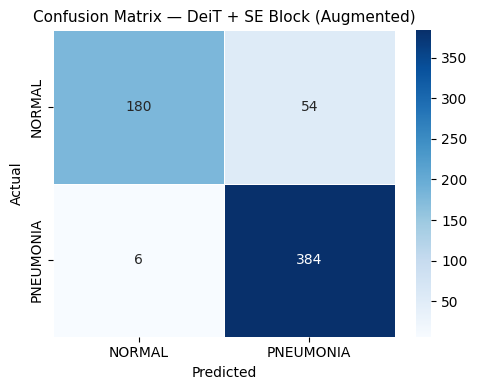

In [29]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — DeiT + SE Block (Augmented)', fontsize=11)
plt.tight_layout(); plt.show()

In [30]:
# ── 3-way comparison: Baseline vs Augmented vs SE+Augmented ───────────────────
compare_data = [
    ('Baseline',       m_base),
    ('Augmented',      m_aug),
    ('SE + Augmented', m_se_aug),
]

rows = []
for setup, m in compare_data:
    rows.append({
        'Setup'         : setup,
        'Accuracy'      : m['Accuracy'],
        'Precision'     : m['Precision'],
        'Recall'        : m['Recall'],
        'F1 Score'      : m['F1 Score'],
        'Size (MB)'     : m['Model Size (MB)'],
        'Params (M)'    : m['Total Params (M)'],
        'Total Time (s)': m['Total Time (s)'],
        'Avg Epoch (s)' : m['Avg Epoch (s)'],
    })

final_df = pd.DataFrame(rows)
print('\n======= FINAL 3-WAY COMPARISON =======')
print(final_df.to_string(index=False))
final_df.to_csv('/kaggle/working/deit_final_comparison.csv', index=False)


======= FINAL 3-WAY COMPARISON =======
         Setup  Accuracy  Precision  Recall  F1 Score  Size (MB)  Params (M)  Total Time (s)  Avg Epoch (s)
      Baseline    0.8990     0.9061  0.8990    0.8961     328.87       86.19          1041.4          104.1
     Augmented    0.9087     0.9107  0.9087    0.9072     328.87       86.19          1697.8          113.2
SE + Augmented    0.9038     0.9108  0.9038    0.9011     330.00       86.49          1695.2          113.0


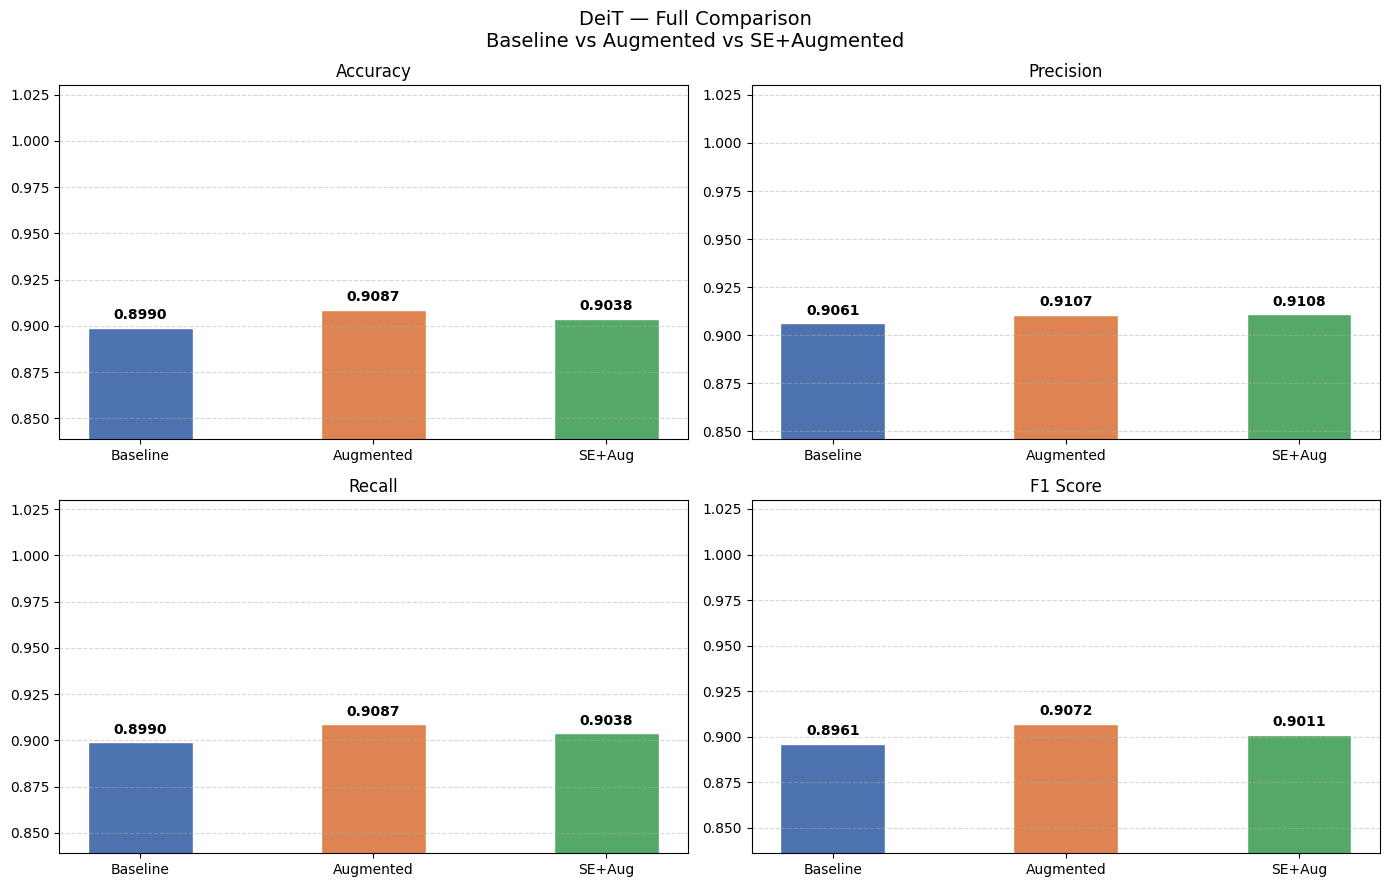

In [31]:
# ── Bar chart: 3-way ──────────────────────────────────────────────────────────
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors       = ['#4C72B0', '#DD8452', '#55A868']
x_labels     = ['Baseline', 'Augmented', 'SE+Aug']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('DeiT — Full Comparison\nBaseline vs Augmented vs SE+Augmented',
             fontsize=14)

for ax, metric in zip(axes.flat, metrics_list):
    vals = final_df[metric].values
    bars = ax.bar(x_labels, vals, color=colors, edgecolor='white', width=0.45)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(max(0, vals.min() - 0.06), 1.03)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{bar.get_height():.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout(); plt.show()

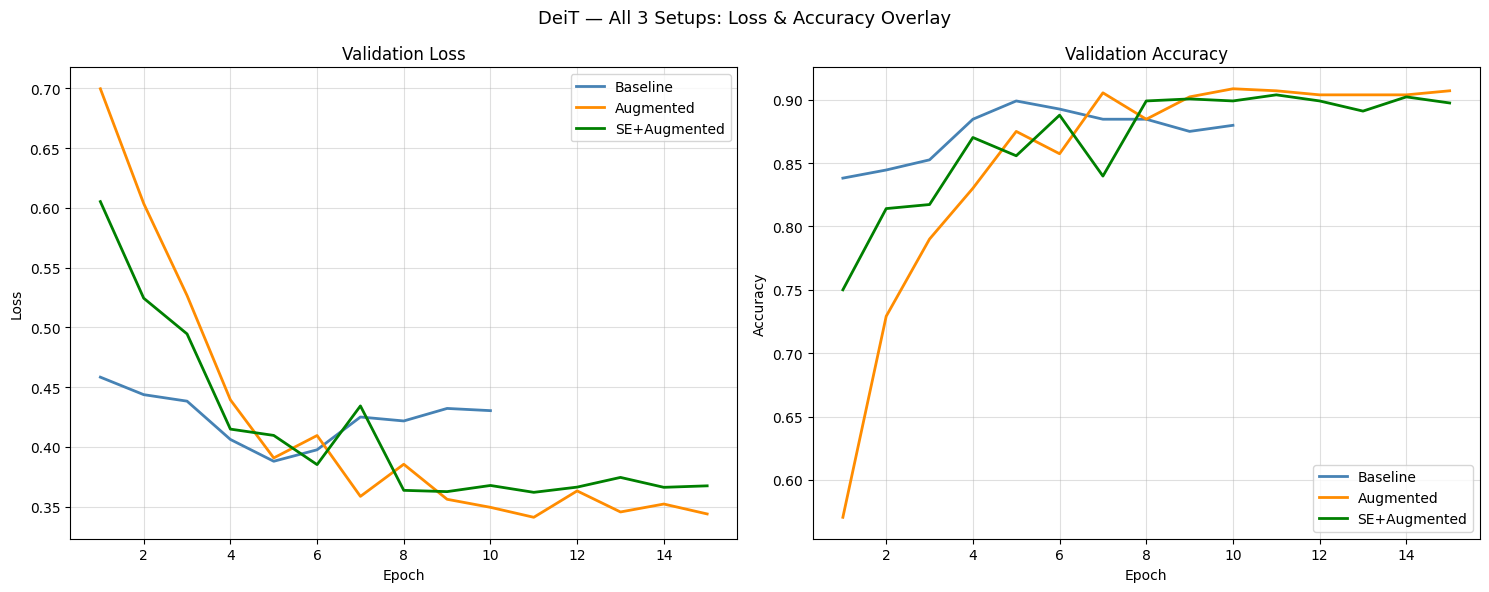

In [32]:
# ── Overlay all 3 val accuracy curves ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('DeiT — All 3 Setups: Loss & Accuracy Overlay', fontsize=13)

for hist, lbl, col in [
    (hist_base,   'Baseline',       'steelblue'),
    (hist_aug,    'Augmented',      'darkorange'),
    (hist_se_aug, 'SE+Augmented',   'green'),
]:
    ep = range(1, len(hist['train_loss']) + 1)
    axes[0].plot(ep, hist['val_loss'], color=col, lw=2, label=lbl)
    axes[1].plot(ep, hist['val_acc'],  color=col, lw=2, label=lbl)

axes[0].set_title('Validation Loss'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout(); plt.show()

In [33]:
# ── Final summary ─────────────────────────────────────────────────────────────
print('=' * 60)
print('DeiT — FINAL SUMMARY')
print('=' * 60)
print(final_df[['Setup', 'Accuracy', 'F1 Score',
                'Params (M)', 'Total Time (s)']].to_string(index=False))

best = final_df.loc[final_df['Accuracy'].idxmax()]
print(f'\n✅  Best setup : {best["Setup"]}')
print(f'    Accuracy  : {best["Accuracy"]}')
print(f'    F1 Score  : {best["F1 Score"]}')

se_gain = m_se_aug['Accuracy'] - m_aug['Accuracy']
print(f'\n📊  SE Block gain over Augmented: {se_gain:+.4f}')

DeiT — FINAL SUMMARY
         Setup  Accuracy  F1 Score  Params (M)  Total Time (s)
      Baseline    0.8990    0.8961       86.19          1041.4
     Augmented    0.9087    0.9072       86.19          1697.8
SE + Augmented    0.9038    0.9011       86.49          1695.2

✅  Best setup : Augmented
    Accuracy  : 0.9087
    F1 Score  : 0.9072

📊  SE Block gain over Augmented: -0.0049
